<a href="https://colab.research.google.com/github/it25101136/IT2011-Stress-Level-Prediction-/blob/Chanul/6_Weerasekara_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Shared Setup: Load Data and Split
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split
import os

drive.mount('/content/drive', force_remount=True)

df_master = pd.read_csv('/content/drive/MyDrive/IT2011_G12_AI_Project/results/outputs/FINAL_ML_READY_DATA.csv')


# FIX: Drop BOTH the target category and the direct score to prevent data leakage
X = df_master.drop(columns=['stress_level', 'stress_score'])
y = df_master['stress_level']

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Mounted at /content/drive
Training data shape: (2400, 7)
Testing data shape: (600, 7)


In [2]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

print("Executing Member 6 Model: MLP Neural Network")

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.05]
}

mlp = MLPClassifier(max_iter=2000, random_state=42)
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Optimum Parameters found: {grid_search.best_params_}")
print(f"Validation Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

pd.DataFrame({'Model': ['MLP Neural Network'], 'Accuracy': [accuracy]}).to_csv(
    '/content/drive/MyDrive/IT2011_G12_AI_Project/results/outputs/Score_Weerasekara.csv', index=False)

Executing Member 6 Model: MLP Neural Network
Optimum Parameters found: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50)}
Validation Accuracy: 0.6967

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.29      0.40        62
           1       0.73      0.73      0.73       239
           2       0.67      0.76      0.71       299

    accuracy                           0.70       600
   macro avg       0.69      0.59      0.62       600
weighted avg       0.70      0.70      0.69       600



In [3]:
import pandas as pd

# Convert grid search CV results to a DataFrame
cv_results_df = pd.DataFrame(grid_search.cv_results_)

print(f"Total hyperparameter combinations evaluated: {len(cv_results_df)}")

# Select and rename key columns for better readability
table_df = cv_results_df[[
    'param_activation',
    'param_alpha',
    'param_hidden_layer_sizes',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].rename(columns={
    'param_activation': 'Activation Function',
    'param_alpha': 'Alpha (Regularization)',
    'param_hidden_layer_sizes': 'Hidden Layer Size',
    'mean_test_score': 'Mean Accuracy',
    'std_test_score': 'Std Dev',
    'rank_test_score': 'Rank'
})

# Sort by rank
table_df = table_df.sort_values(by='Rank')

# Display the table
display(table_df)

Total hyperparameter combinations evaluated: 12


,Activation Function,Alpha (Regularization),Hidden Layer Size,Mean Accuracy,Std Dev,Rank
8,tanh,0.0001,"(50, 50)",0.695833,0.015253,1
3,relu,0.0500,"(50,)",0.695833,0.012290,2
5,relu,0.0500,"(50, 50)",0.694583,0.012679,3
0,relu,0.0001,"(50,)",0.694583,0.015624,3
6,tanh,0.0001,"(50,)",0.694167,0.014988,5
9,tanh,0.0500,"(50,)",0.693333,0.013718,6
11,tanh,0.0500,"(50, 50)",0.693333,0.013527,6
4,relu,0.0500,"(100,)",0.691667,0.020875,8
10,tanh,0.0500,"(100,)",0.690417,0.010086,9
7,tanh,0.0001,"(100,)",0.690417,0.008700,10


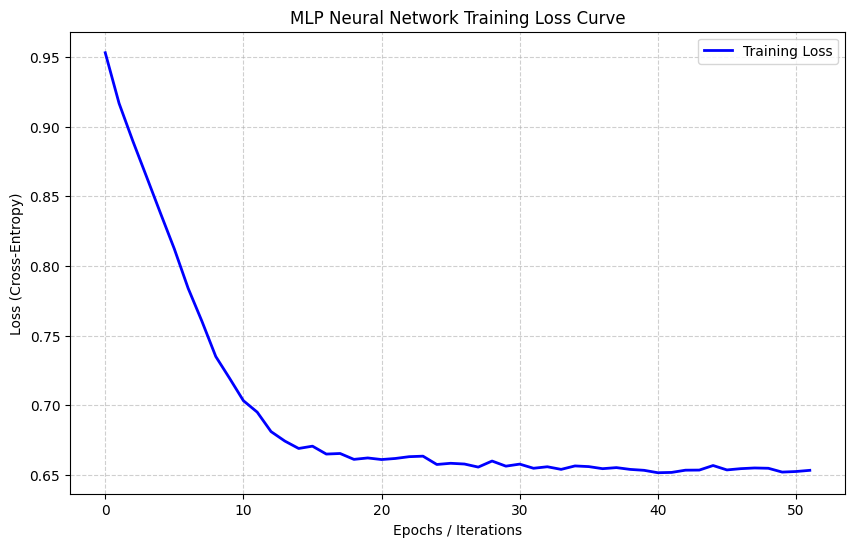

In [4]:
import matplotlib.pyplot as plt

# Retrieve loss curve from the best estimator
loss_values = best_model.loss_curve_

# Plot the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(loss_values, label='Training Loss', color='b', linewidth=2)
plt.title('MLP Neural Network Training Loss Curve')
plt.xlabel('Epochs / Iterations')
plt.ylabel('Loss (Cross-Entropy)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()